# SAM RTN Quantization Analysis

This notebook provides a comprehensive analysis of RTN (Round-to-Nearest) quantization for SAM models, focusing on MSE measurement across attention layers.


In [1]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1" 

from encoder_quant import (
    image_encoder_monkey_patch, 
    ImageEncoderViTObserver
) 
from utils import get_activation_boxplot, to_numpy,  inference_image
from segment_anything import SamPredictor, sam_model_registry
import matplotlib.pyplot as plt
from quant_utils import SignProcessor, DoNothingProcessor, AttnBasedProcessor
from segment_anything.modeling.image_encoder import (
    Attention,
    Block,
    ImageEncoderViT,
)
from quant_utils import ImageEncoderProcessor
from segment_anything.modeling.image_encoder import (
    window_partition,
    window_unpartition,
)
from segment_anything.modeling.image_encoder import add_decomposed_rel_pos

/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/segment_anything/modeling/tiny_vit_sam.py:662: UserWarning: Overwri

In [2]:

model_type = 'vit_l'
checkpoint_path= './pretrained_checkpoint/sam_hq_vit_l.pth'
sam = sam_model_registry[model_type](checkpoint=checkpoint_path).to('cuda')


predictor = SamPredictor(sam)
processor = ImageEncoderProcessor('attn') 
# processor = DoNothingProcessor('attn') 
# processor = SignProcessor('attn') 
# processor.calibrate(
    # predictor=predictor, 
    # modules=(),
    # num_samples=1,
# )
predictor = SamPredictor(sam)
image_encoder_monkey_patch(predictor.model, processor, n_bits=8, debug=True)


<All keys matched successfully>
------------------------------ valid --------------------------------
--->>> valid  dataset  0 / 1   DIS5K-VD <<<---
-im- DIS5K-VD ./data/DIS5K/DIS-VD/im :  470
-gt- DIS5K-VD ./data/DIS5K/DIS-VD/gt :  470


(1000, 894, 3)


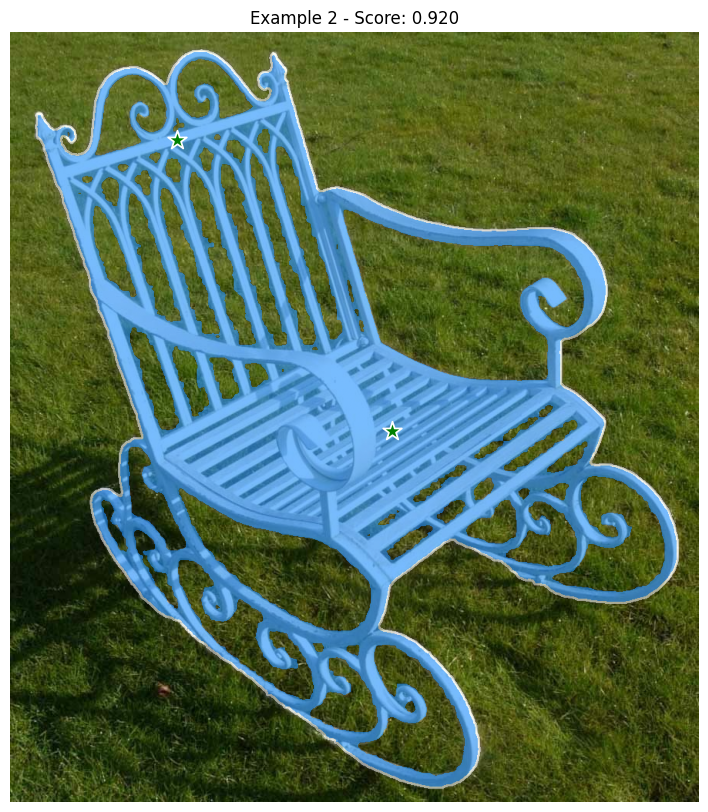

(array([[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]],
       shape=(1, 1000, 894)),
 array([0.91993], dtype=float32),
 array([[[ -9.819817 , -12.19165  , -10.208868 , ...,  -8.438784 ,
           -9.517096 ,  -9.359494 ],
         [-10.38857  , -13.301583 ,  -9.985376 , ...,  -9.34211  ,
          -10.048056 , -10.236759 ],
         [-10.228151 , -12.927952 , -10.906278 , ...,  -9.326048 ,
          -11.062877 , -10.994862 ],
         ...,
         [ -7.5699973, -11.632122 , -10.298674 , ...,  -5.1798606,
           -7.000796 ,  -6.512075 ],
         [ -9.654377 , -11.936314 , -11.072433 , ...,  -7.0241604,
           -8.113507 ,  -7.5489454],
         [-10.051227 , -11.582567 , -1

In [6]:
# results = inference_image(predictor, image_dir='./input_imgs/', example_idx=3, show_image=True)
# for i in range(5):
inference_image(predictor, image_dir='./input_imgs/', example_idx=2, show_image=True)

In [7]:
ImageEncoderViTObserver.attention_score.keys()

dict_keys(['block_0_x', 'block_0_attn', 'block_0_attn_mean', 'block_0_q', 'block_0_k', 'block_0_v', 'block_0_q_mean', 'block_0_v_mean', 'block_1_x', 'block_1_attn', 'block_1_attn_mean', 'block_1_q', 'block_1_k', 'block_1_v', 'block_1_q_mean', 'block_1_v_mean', 'block_2_x', 'block_2_attn', 'block_2_attn_mean', 'block_2_q', 'block_2_k', 'block_2_v', 'block_2_q_mean', 'block_2_v_mean', 'block_3_x', 'block_3_attn', 'block_3_attn_mean', 'block_3_q', 'block_3_k', 'block_3_v', 'block_3_q_mean', 'block_3_v_mean', 'block_4_x', 'block_4_attn', 'block_4_attn_mean', 'block_4_q', 'block_4_k', 'block_4_v', 'block_4_q_mean', 'block_4_v_mean', 'block_5_x', 'block_5_attn', 'block_5_attn_mean', 'block_5_q', 'block_5_k', 'block_5_v', 'block_5_q_mean', 'block_5_v_mean', 'block_6_x', 'block_6_attn', 'block_6_attn_mean', 'block_6_q', 'block_6_k', 'block_6_v', 'block_6_q_mean', 'block_6_v_mean', 'block_7_x', 'block_7_attn', 'block_7_attn_mean', 'block_7_q', 'block_7_k', 'block_7_v', 'block_7_q_mean', 'block_

In [12]:

def get_attention_map(layer_idx:int):
    attn = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_attn'][0]
    return attn

def get_attention_map_mean(layer_idx:int):
    attn = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_attn_mean'][0]
    return attn

def get_feature(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_x'][0]
    return x
def get_q(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_q'][0]
    return x
def get_k(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_k'][0]
    return x
def get_v(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_v'][0]
    return x

def get_q_mean(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_q_mean'][0]
    return x
def get_v_mean(layer_idx:int):
    x = ImageEncoderViTObserver.attention_score[f'block_{layer_idx}_v_mean'][0]
    return x




In [16]:
get_attention_map_mean(5).shape

(16, 1, 4096)

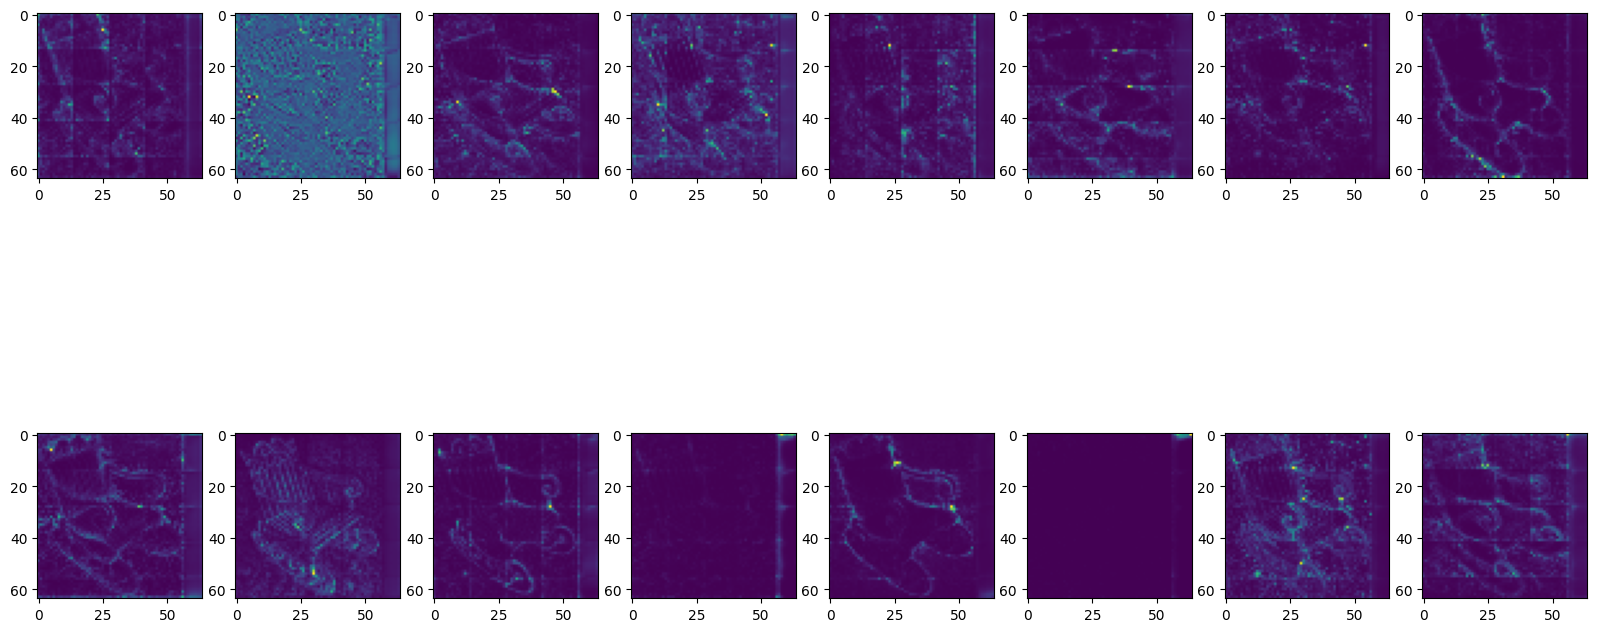

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot  as plt

def cal_energy(X:torch.Tensor, margin=0.9):
    """
    Calculate the energy of the input tensor.
    """
    X = F.normalize(X.reshape(-1, X.shape[-1]), dim=-1, p=2)
    score_map = F.elu(X @ X.transpose(-1, -2) - margin)
    scores = score_map.mean(-1)
    return scores

def recal_attn(q, k, v):
    attn = (q * 1/8) @ k.transpose(-2, -1)
    attn = attn.softmax(dim=-1)
    return attn

head_idx = 0
layer_idx = 17 
q = get_q(layer_idx)[head_idx]
k = get_k(layer_idx)[head_idx]
v = get_k(layer_idx)[head_idx]

ori_attn = get_attention_map(layer_idx)
# attn_mean = get_attention_map(layer_idx)


# plt.imshow(ori_attn.mean(-1).reshape(64,64))
fig, axes = plt.subplots(2,8,figsize=(20,10))
for i in range(8):
    axes[0][i].imshow(ori_attn[2*i].mean(0).reshape(64,64))
    axes[1][i].imshow(ori_attn[2*i+1].mean(0).reshape(64,64))
# print(energy_scores.shape)

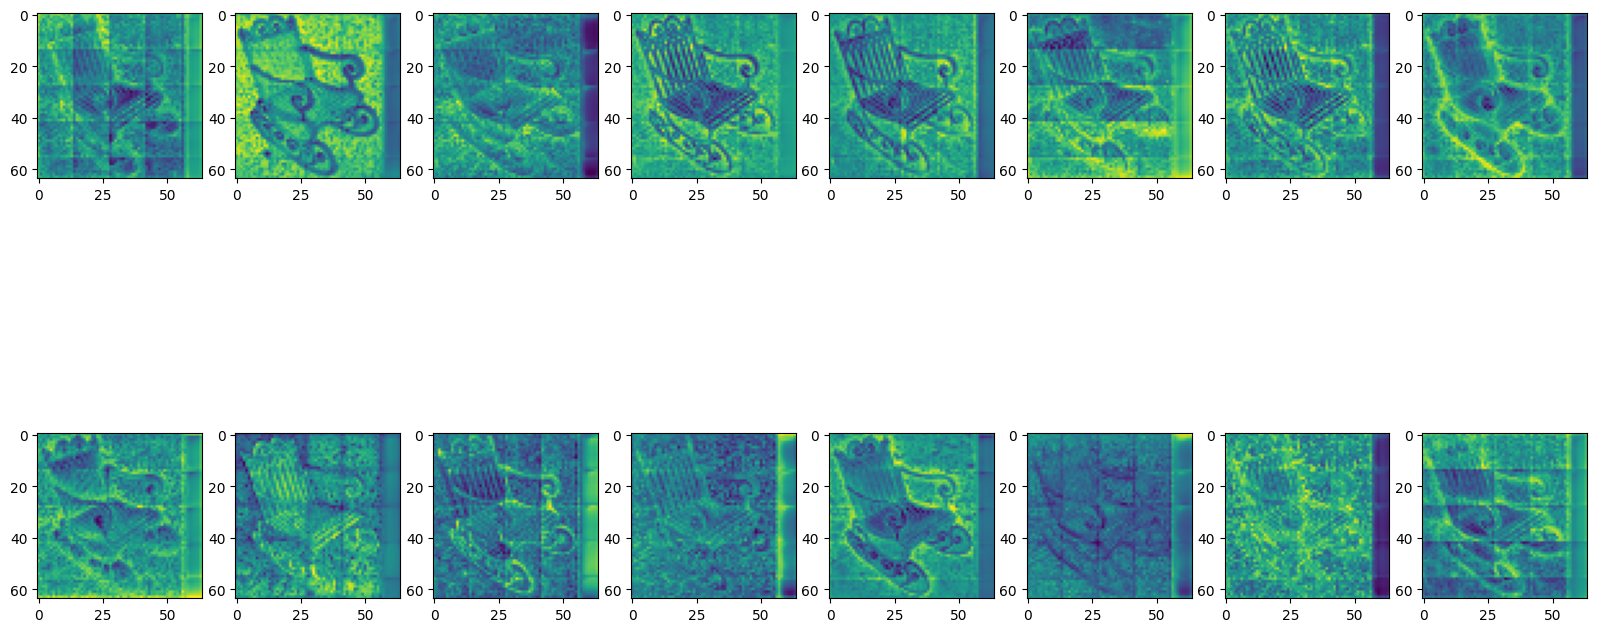

In [ ]:
attn_mean = get_attention_map_mean(layer_idx)


# plt.imshow(ori_attn.mean(-1).reshape(64,64))
fig, axes = plt.subplots(2,8,figsize=(20,10))
for i in range(8):
    axes[0][i].imshow(attn_mean[2*i].mean(0).reshape(64,64))
    axes[1][i].imshow(attn_mean[2*i+1].mean(0).reshape(64,64))

torch.Size([4096])


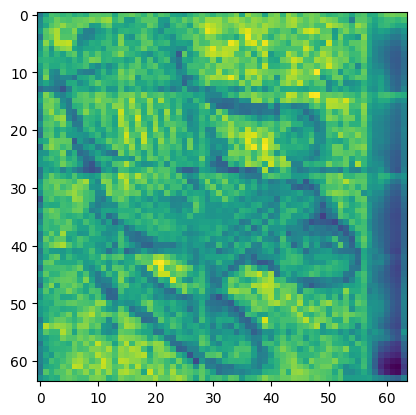

In [25]:
energy_scores =cal_energy(torch.from_numpy(q))
plt.imshow(energy_scores.reshape(64,64))
print(energy_scores.shape)

In [16]:
ori_attn.shape
re_cal_attn.shape

NameError: name 're_cal_attn' is not defined

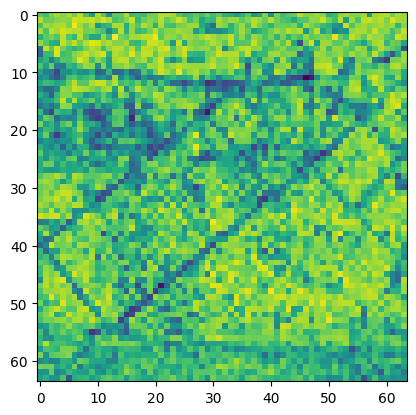

In [ ]:
plt.imshow(energy_scores.reshape(64,64))